In [46]:
#pip install opencv-python

In [47]:
import os
import re
import cv2 # opencv library
import numpy as np
from os.path import isfile, join
import matplotlib.pyplot as plt

In [48]:
col_frames = os.listdir('./Webcam Computer Vision/')
col_frames

['camera0 (1).jpg',
 'camera0 (2).jpg',
 'camera0.jpg',
 'GRCA webcam no vehicles 11282022.jpg',
 'GRCA webcam work zone.jpg',
 'webcam_output_11142022.jpg',
 'webcam_output_11212022.jpg',
 'webcam_output_11212022_1.jpg']

In [49]:
col_images = []

In [50]:
for i in col_frames:
    # read the frames
    img = cv2.imread('./Webcam Computer Vision/'+i)
    # append the frames to the list
    col_images.append(img)

In [51]:
len(col_images)

8

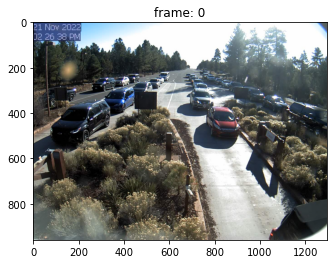

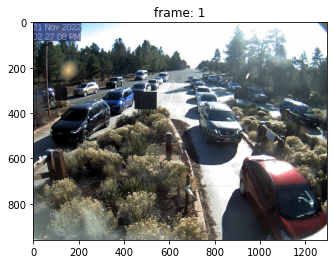

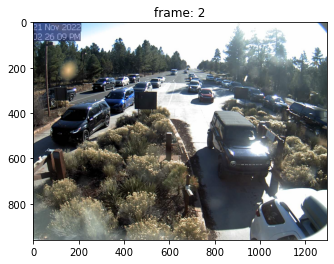

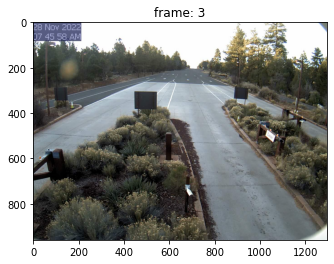

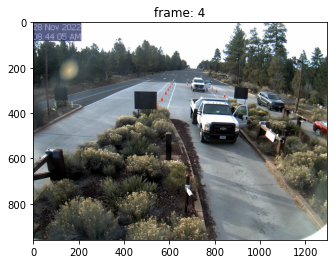

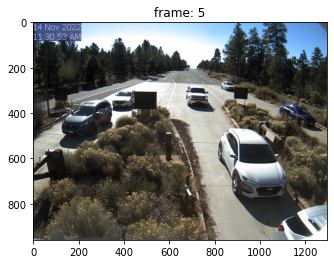

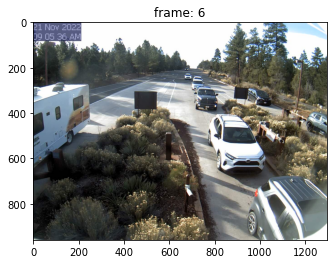

In [52]:
i = 0
for frame in range(i, len(col_images)-1):
    plt.imshow(cv2.cvtColor(col_images[frame], cv2.COLOR_BGR2RGB))
    plt.title("frame: "+str(frame))
    plt.show()

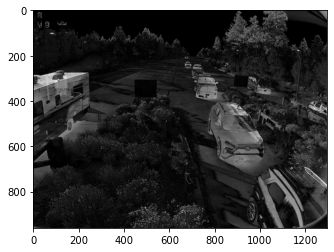

In [53]:
# convert the frames to grayscale
to_analyze = 6
grayA = cv2.cvtColor(col_images[3], cv2.COLOR_BGR2GRAY)
grayB = cv2.cvtColor(col_images[to_analyze], cv2.COLOR_BGR2GRAY)
#grayC = cv2.cvtColor(col_images[i+1], cv2.COLOR_BGR2GRAY)
# plot the image after frame differencing
plt.imshow(cv2.absdiff(grayB, grayA), cmap = 'gray')
plt.show()

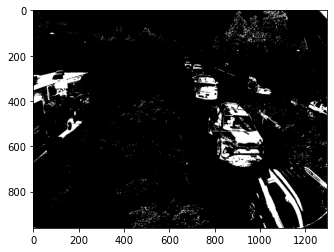

In [54]:
diff_image = cv2.absdiff(grayB, grayA)

# perform image thresholding
ret, thresh = cv2.threshold(diff_image, 100, 255, cv2.THRESH_BINARY)

# plot image after thresholding
plt.imshow(thresh, cmap = 'gray')
plt.show()

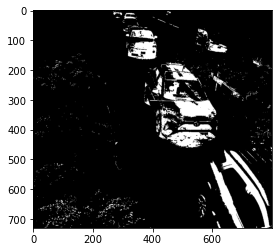

In [55]:
cropped_image = thresh[230:1000,400:1200] # Slicing to crop the image

#cv2.line(dmy, (0, 200),(1200,200),(100, 255, 255))
#cropped = img[start_row:end_row, start_col:end_col]
# Display the cropped image
plt.imshow(cropped_image, cmap = 'gray')
plt.show()

In [56]:
# apply image dilation
kernel = np.ones((3,3),np.uint8)
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

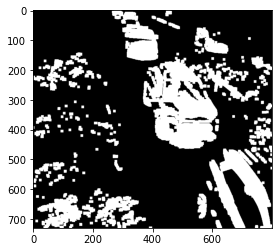

In [57]:
dilated = cv2.dilate(cropped_image,kernel,iterations = 4)

# plot dilated image
plt.imshow(dilated, cmap = 'gray')
plt.show()

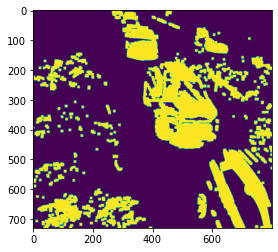

In [58]:
# plot vehicle detection zone
plt.imshow(dilated)
cv2.line(dilated, (0, 200),(1200,200),(100, 255, 255))
#cv2.line(dmy, (0, 200),(1200,200),(100, 255, 255))

plt.show()

In [59]:
contours, hierarchy = cv2.findContours(cropped_image.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)


In [60]:
valid_cntrs = []

for i,cntr in enumerate(contours):
    x,y,w,h = cv2.boundingRect(cntr)
    #if (x <= 200) & (y >= 80) & (cv2.contourArea(cntr) >= 25):
    # If contr length is above X, add append it
    valid_cntrs.append(cntr)

# count of discovered contours        
len(valid_cntrs)

1550

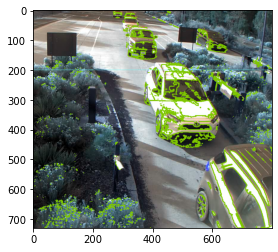

In [61]:
dmy = col_images[to_analyze].copy()
dmy = dmy[230:1000,400:1200]


cv2.drawContours(dmy, valid_cntrs, -1, (127,200,0), 2)
cv2.line(dmy, (0, 200),(1200,200),(100, 255, 255))
plt.imshow(dmy)
plt.show()

# Could you do k means after this?

#Next Questions:
# Is there a car, yes or no? (Make this a function?)
# How far back does the line go?
# extra: crop the lane non rectangular shape
# Save the output image 

3

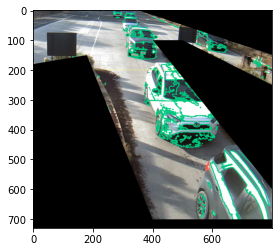

In [63]:
# original image
# -1 loads as-is so if it will be 3 or 4 channel as the original
image = dmy
# mask defaulting to black for 3-channel and transparent for 4-channel
# (of course replace corners with yours)
mask = np.zeros(image.shape, dtype=np.uint8)
roi_corners = np.array([[(0,0),(0,180), (180,150), (400,700),(800,700),(800,600),(400,100),(500,100),(800,250),(800,150),(350,0)]], dtype=np.int32)
# fill the ROI so it doesn't get wiped out when the mask is applied
channel_count = image.shape[2]  # i.e. 3 or 4 depending on your image
ignore_mask_color = (255,)*channel_count
cv2.fillPoly(mask, roi_corners, ignore_mask_color)
# from Masterfool: use cv2.fillConvexPoly if you know it's convex

# apply the mask
masked_image = cv2.bitwise_and(image, mask)

#plt.masked_image
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
channel_count